# Notebook Redes neuronales 

Acá vamos a entrenar usando pytorch, tanto una red superficial como una profunda con los mismos datos para ver la diferencia. Lo que queremos resolver es entrenar usando los datos MNIST. El objetivo es clasificar datos escritos a mano, la red neuronal va a leer imagenes de en escala de grises de 28x28 píxeles y queremos que clasifique cada una de estas imágenes como un dígito entre 0 y 9. 
- Input: imagenes de MNISt, tensor de forma (batch_size, 1, 28, 28) con valores normalizados
- Output: vector de logits de tamaño 10, uno por cada dígito posible. El índice del valor máximo es equiparable a la predicción. 

Librerias que usaremos y para que sirven: 
- torch: paquete central de PyTorch; contiene tensores y las operaciones sobre ellos.
- torch.nn: módulos y capas de red (e.g., Linear, ReLU, CrossEntropyLoss).
- torch.optim: optimizadores (e.g., Adam, SGD) que actualizan los pesos.
- torchvision.datasets: colecciones de datasets comunes; usamos MNIST para descargar y leer imágenes.
- torchvision.transforms: transformaciones de preprocessing (e.g., pasar a tensor, normalizar).
- torch.utils.data.DataLoader: iterador eficiente de minibatches, shuffle y multi‑threading.
- matplotlib.pyplot: graficación (mostramos curvas de pérdida y ejemplos de imágenes).


¿Por qué las imágenes en Deep Learning van a ser un tensor 4D?
- **batch_size**: número de imágenes procesadas a la vez (minibatch).  
- **canales**: número de “canales” de color.  
  - En imágenes en escala de grises (MNIST) es 1 canal.  
  - En imágenes RGB sería 3 canales (rojo, verde, azul).  
- **alto** y **ancho**: dimensiones en píxeles de cada imagen (28×28 en MNIST).

### Preliminares: 

Primero cargamos los datos y vemos como se ven: 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Parámtro general para las dos redes: 
batch_size = 64 # Número de ejemplos procesados en cada paso de optimización

# Transformaciones
# Convierte la imagen cargada (PIL) en un tensor de forma (C, H, W) con valores en [0.0, 1.0]
# PIL (Python Imaging Library): es una biblioteca en Python para cargar y manipular imágenes.  
# Cuando usamos `datasets.MNIST(..., transform=ToTensor())`, cada imagen original en formato PIL se convierte en un tensor PyTorch.  
#Ejemplo de flujo:  
#  1. Descargamos un archivo `.png` o `.jpg`.  
#  2. `PIL.Image.open()` lo carga como objeto **PIL Image**.  
#  3. `transforms.ToTensor()` lo convierte en un tensor con valores en `[0,1]`.
# Normaliza cada canal restando la media 0.1307 y dividiendo por la desviación estándar 0.3081. 
# Este par (mean, std) es el promedio y desviación empírica de todo MNIST y ayuda a que el entrenamiento sea más estable.
tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

## Carga de datos: acá descargamos los datos de MNIST y aplicamos lo siguiente: 
## ToTensor(): convierte cada imagen a un tensor float en [0,1]
## Noramalize((0.1307,), (0.3081,)): centra y escala el pixel por canal
## DataLoader agrupa en lotes de 64
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=tfms)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=tfms)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")

Train samples: 60000, Test samples: 10000


## Visualización de ejemplos de MNIST
Mostramos una cuadrícula de 9 dígitos tomados del conjunto de entrenamiento.

## 1. Red Neuronal Superficial: 

Arquitectura de la red

- Capa de entrada: 28×28 = 784 neuronas (la imagen “aplanada”).
- Capa oculta: 512 unidades con función de activación ReLU.
- Capa de salida: 10 unidades sin activación (seguirá CrossEntropyLoss que aplica Softmax internamente).

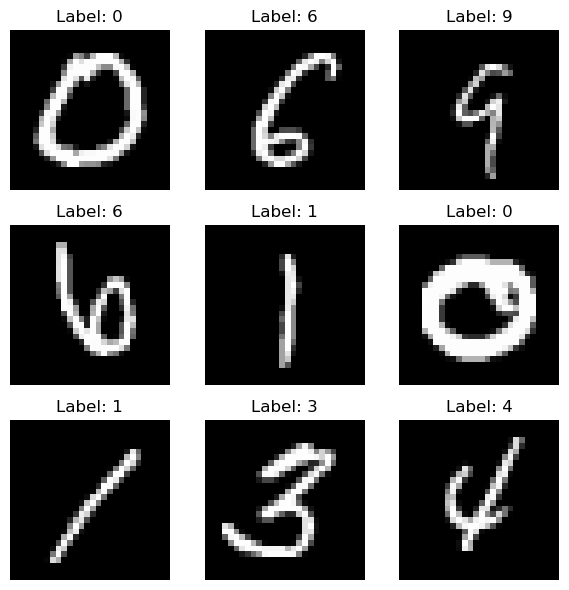

In [3]:
import matplotlib.pyplot as plt

# Obtener un batch de entrenamiento
# Extrae un minibatch (64 ejemplos) y muestra 9 dígitos con su etiqueta
# Objetivo: familiarizarse con la forma y rango de los datos. 
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Visualizar 9 imágenes
fig, axes = plt.subplots(3, 3, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Estructura de la red neuronal senicilla: 
input_dim = 28*28 # Cada imagen MNIST es de 28×28 píxeles → vectores de longitud 784
hidden_dim = 512 # Cantidad de neuronas en la capa oculta (suficiente para capturar patrones sin ser profunda)
output_dim = 10 # Clases posibles: dígitos 0–9

# Definimos nuestra red neuronal superficial usando el modulo de pytorch 
class ShallowMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

# Acá usamos nn.Sequential que en general funciona bien para redes no muy complicadas pero si queremos ser mas explicitos podriamos 
# usar: esto es mas código pero para redes más complicados nos va a ayudar a hacer debug, congelar capas, cambiar activaciones, etc 

# class ShallowMLP(nn.Module):
#     def __init__(self, input_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.fc1  = nn.Linear(input_dim, hidden_dim)
#         self.relu = nn.ReLU()
#         self.fc2  = nn.Linear(hidden_dim, output_dim)

#     def forward(self, x):
#         x = x.view(x.size(0), -1)
#         x = self.fc1(x)
#         x = self.relu(x)
#         x = self.fc2(x)
#         return x




model = ShallowMLP(input_dim, hidden_dim, output_dim)
print(model)

## Entrenamos nuestra red superficial: 

#Permite usar GPU si está disponible, acelerando el entrenamiento.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
#Función de pérdida que vamos a usar, en este caso crossEntropy porque tenemos un problema de clasificación multiclase 
criterion = nn.CrossEntropyLoss()
#Algorítmo de optimización que vamos a usar, mas de esto en próximas clases. Existen 
#Muchos de estos no solo GD y SGD
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5
train_losses = []

#model.train() activa capas como Dropout/BatchNorm (no usada aquí pero buena práctica).
#Por cada minibatch este código va a: 
#1. zero_grad() limpia los gradientes
#2. Forward -> corre la red hacia adelante
#3. Calcula la función de pérdida dato el output generado en forward 
#4. Backward propagation -> para encontrar los nuevos pesos
#5. step() -> actualiza los pesos 
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0
    for data, targets in train_loader:
        data, targets = data.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.4f}")


ShallowMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
Epoch 1/5 - Loss: 0.2037
Epoch 2/5 - Loss: 0.0825
Epoch 3/5 - Loss: 0.0559
Epoch 4/5 - Loss: 0.0428
Epoch 5/5 - Loss: 0.0329


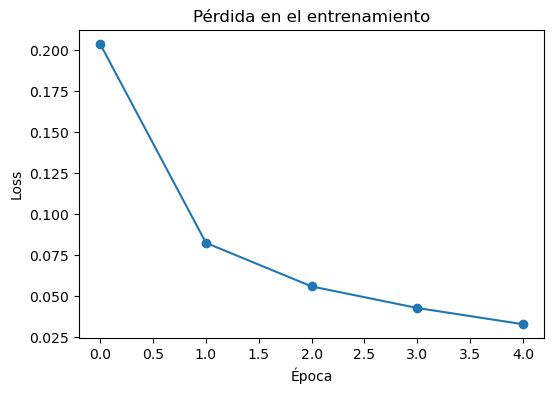

Test Accuracy: 97.56%


In [6]:
### Como lo hizo nuestra red neuronal superficial: 

#Grafica el valor promedio de la pérdida por época para verificar convergencia
plt.figure(figsize=(6,4))
plt.plot(train_losses, marker='o')
plt.title('Pérdida en el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.show()

## model.eval() desactiva capas sensibles al estado de entrenamiento.
## torch.no_grad() ahorra memoria y tiempo al no calcular gradientes.
##Se calcula la precisión global sobre los 10 000 ejemplos de test.

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
print(f"Test Accuracy: {100 * correct/total:.2f}%")

## 2. Red Neuronal Profunda 

In [7]:

## Definimos los inputs de nuestra red profunda 
input_dim = 28*28
hidden_dim1 = 512
hidden_dim2 = 256
output_dim = 10

# Acá lo único que cambia es que tenemos dos capas ocultas, antes solo teniamos 1 
# Declaras una nueva clase DeepMLP que hereda de nn.Module, la clase base de todos los modelos en PyTorch.
# def __init__(…): El método constructor recibe cuatro parámetros 
# input_dim: dimensión del vector de entrada (por ejemplo, 784 para imágenes 28×28)
# hidden1: número de neuronas en la primera capa oculta.
# hidden2: número de neuronas en la segunda capa oculta.
# output_dim: dimensión de salida (por ejemplo, 10 para dígitos 0–9)
# super().__init__(): Llama al constructor de nn.Module para inicializar la infraestructura interna (registros de sub-módulos, parámetros, etc.).
# self.net = nn.Sequential(...) (sequential.. la red es secuencial)crea un único submódulo llamado net que encadena, en orden una 
# capa lineal (fully connected) que mapea
# el input a la primera capa intermedia, lo pasa por una función de activación ReLU y lo manda a una segunda capa intermedia lineal
# lo pasa otra vez por ReLu y por último una capa lineal que produce los logits de salida
# forward(self, x): Define cómo fluye un batch de entrada x a través de la red.
# x.view(x.size(0), -1) aplana cada imagen de tamaño (canales, alto, ancho) a un vector unidimensional (batch_size, input_dim)
# x.size(0) es el batch_size; -1 le dice a PyTorch que calcule automáticamente la otra dimensión.
# self.net(x): aplica todas las capas lineales y activaciones de forma secuencial, y devuelve un tensor de forma (batch_size, output_dim)

class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_dim)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


 ## Aca la manera mas larga de escribir lo mismo sin sequential: 

#  class DeepMLP(nn.Module):
#     def __init__(self, input_dim, hidden1, hidden2, output_dim):
#         super().__init__()
#         self.fc1   = nn.Linear(input_dim,  hidden1)
#         self.relu1 = nn.ReLU()
#         self.fc2   = nn.Linear(hidden1,    hidden2)
#         self.relu2 = nn.ReLU()
#         self.fc3   = nn.Linear(hidden2,    output_dim)

#     def forward(self, x):
#         x = x.view(x.size(0), -1)
#         x = self.fc1(x); x = self.relu1(x)
#         x = self.fc2(x); x = self.relu2(x)
#         x = self.fc3(x)
#         return x       


# Se crea un objeto model con los tamaños deseados
model = DeepMLP(input_dim, hidden_dim1, hidden_dim2, output_dim)
print(model)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

train_losses = []
train_accs = []

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for data, targets in train_loader:
        data, targets = data.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    train_losses.append(avg_loss)
    train_accs.append(accuracy)
    print(f"Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.4f}, Acc: {accuracy:.2f}%")

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Epoch 1/5 - Loss: 0.2029, Acc: 93.83%
Epoch 2/5 - Loss: 0.0862, Acc: 97.28%
Epoch 3/5 - Loss: 0.0593, Acc: 98.14%
Epoch 4/5 - Loss: 0.0464, Acc: 98.50%
Epoch 5/5 - Loss: 0.0377, Acc: 98.76%


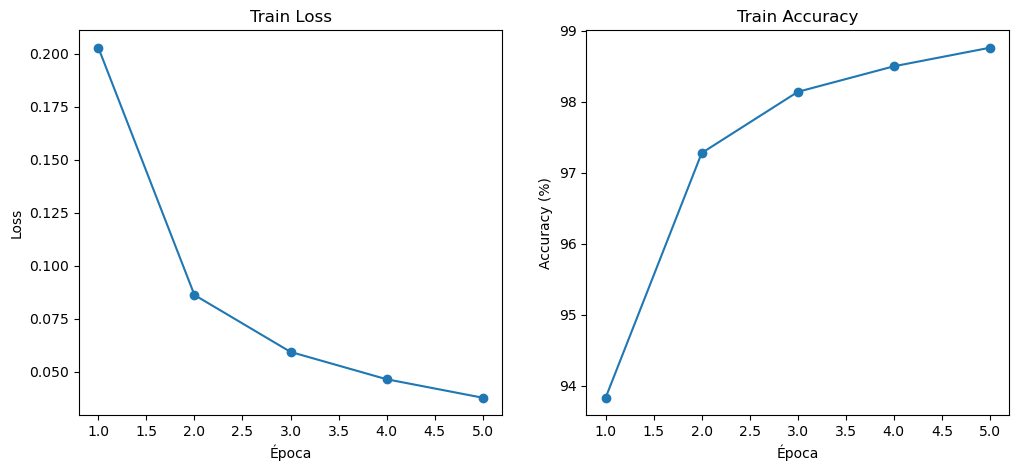

Test Accuracy: 97.75%


In [8]:
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o')
plt.title('Train Loss')
plt.xlabel('Época')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, marker='o')
plt.title('Train Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.show()

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        _, preds = outputs.max(1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
print(f"Test Accuracy: {100 * correct/total:.2f}%")